#  Введение

**Анализ данных по продажам книжной продукции за 2025 год**

**Контекст:** Книжное издательство реализует продукцию через два канала:
- маркетплейс 
- собственный интернет-магазин

**Цель анализа:** Оценить структуру продаж книжного ассортимента и выявить ключевые драйверы выручки и стабильности спроса.
Объект анализа: заказ, канал.

**Период:** 2025.

**Ограничение:** это synthetic data, но данные приближены к реальному бизнесу.

**Задачи**: 
- определить базовые продуктовые метрики (выручка, количество заказов, средний чек)
- выявить ключевые категории товаров на уровне поджанров, которые:
    - формируют основную выручку и объем продаж
    - обеспечивают стабильный спрос
    - требующие внимания или возможного вывода из ассортимента
    - создают риски из-за высокой вариативности продаж.
    - неэффективны с точки зрения вклада в бизнес

# Импорт данных

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from babel.numbers import format_decimal, format_currency, \
    format_compact_decimal, format_compact_currency

from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', '{:.2f}'.format)

sns.set_theme(style="ticks", context="talk")

OUTPUT_DIR = "../data"

In [2]:
df_orders = pd.read_csv(f'{OUTPUT_DIR}/orders.csv',
                        parse_dates=['order_date'],
                        usecols=[
                            'order_id', 'order_date', 'channel',
                            'order_status', 'order_quantity_fulfilled',
                            'net_revenue', 'commission_fee', 'shipping_cost', 
                            'ad_spend', 'product_cost', 'margin'
                        ])
print(f'Заказы: {df_orders.shape}')

df_order_items = pd.read_csv(f'{OUTPUT_DIR}/order_items.csv',
                             usecols=[
                                 'order_item_id', 'order_id', 'product_id',
                                 'quantity_fulfilled', 'unit_price',
                                 'net_revenue', 'item_status'
                             ])
print(f'Состав заказа: {df_order_items.shape}')

df_products = pd.read_csv(f'{OUTPUT_DIR}/products.csv',
                          usecols=['product_id', 'genre', 'subgenre'])

print(f'Продукты: {df_products.shape}')

Заказы: (1000050, 11)
Состав заказа: (1707328, 7)
Продукты: (12000, 3)


In [3]:
df_orders.head()

,order_id,order_date,channel,order_status,order_quantity_fulfilled,commission_fee,shipping_cost,ad_spend,product_cost,net_revenue,margin
0,MP_ORD000000001,2025-01-01,marketplace,completed,1,109.26,141.08,30.55,341.75,682.85,60.21
1,MP_ORD000000002,2025-01-01,marketplace,completed,4,925.49,128.07,0.00,1667.79,4977.49,2256.14
2,MP_ORD000000003,2025-01-01,marketplace,completed,9,948.63,227.36,602.39,2191.15,5585.88,1616.35
3,MP_ORD000000004,2025-01-01,marketplace,completed,1,82.50,157.49,0.00,143.84,458.35,74.52
4,MP_ORD000000005,2025-01-01,marketplace,completed,5,967.31,214.78,321.23,2213.74,4842.66,1125.60


In [4]:
df_order_items.head()

,order_item_id,order_id,product_id,quantity_fulfilled,unit_price,net_revenue,item_status
0,MA_ITEM0000000001,MP_ORD000000001,BK008855,1,853.56,682.85,completed
1,MA_ITEM0000000002,MP_ORD000000002,BK008092,1,1011.70,1011.70,completed
2,MA_ITEM0000000003,MP_ORD000000002,BK001622,1,645.17,548.39,completed
3,MA_ITEM0000000004,MP_ORD000000002,BK003142,2,1708.70,3417.40,completed
4,MA_ITEM0000000005,MP_ORD000000003,BK008335,2,1171.93,2343.86,completed


In [5]:
df_products.head()

,product_id,genre,subgenre
0,BK000001,Non-Fiction,Psychology
1,BK000002,Children,Activity Books
2,BK000003,Fiction,Romance
3,BK000004,Children,Middle Grade
4,BK000005,Comics & Manga,Comics


In [6]:
df = (df_orders.merge(df_order_items, on="order_id", suffixes=(None, '_item'))
               .merge(df_products, on="product_id", suffixes=(None, '_product')))
print(df.shape)
df.head()

(1707328, 19)


,order_id,order_date,channel,order_status,order_quantity_fulfilled,commission_fee,shipping_cost,ad_spend,product_cost,net_revenue,margin,order_item_id,product_id,quantity_fulfilled,unit_price,net_revenue_item,item_status,genre,subgenre
0,MP_ORD000000001,2025-01-01,marketplace,completed,1,109.26,141.08,30.55,341.75,682.85,60.21,MA_ITEM0000000001,BK008855,1,853.56,682.85,completed,Stationery,Journals
1,MP_ORD000000002,2025-01-01,marketplace,completed,4,925.49,128.07,0.00,1667.79,4977.49,2256.14,MA_ITEM0000000002,BK008092,1,1011.70,1011.70,completed,Education,School
2,MP_ORD000000002,2025-01-01,marketplace,completed,4,925.49,128.07,0.00,1667.79,4977.49,2256.14,MA_ITEM0000000003,BK001622,1,645.17,548.39,completed,Fiction,Mystery
3,MP_ORD000000002,2025-01-01,marketplace,completed,4,925.49,128.07,0.00,1667.79,4977.49,2256.14,MA_ITEM0000000004,BK003142,2,1708.70,3417.40,completed,Children,Activity Books
4,MP_ORD000000003,2025-01-01,marketplace,completed,9,948.63,227.36,602.39,2191.15,5585.88,1616.35,MA_ITEM0000000005,BK008335,2,1171.93,2343.86,completed,Stationery,Journals


In [7]:
df["month"] = df["order_date"].dt.to_period("M")

# Базовые метрики

In [8]:
total_revenue = df_orders["net_revenue"].sum()
print(f"💰Выручка: {total_revenue:,.0f} руб.")

profit = df_orders["margin"].sum()
print(f"💸Маржинальная прибыль: {profit:,.0f} руб.")

avg_check = df_orders["net_revenue"].mean()
print(f"🧾Средний чек: {avg_check:,.2f} руб.")


print("\n=== 🛒Заказы ===")
total_orders = df_orders["order_id"].nunique()
print(f"Общее количество заказов: {total_orders}")
status_counts = df_orders['order_status'].value_counts()
print("В разрезе статуса выполнения:")
for status, count in status_counts.items():
    print(f"  • {status:<15} {count:>6}")

total_quantity = df_order_items[df_order_items["item_status"] ==
                                'completed']["quantity_fulfilled"].sum()

print("\n===📦 Товары ===")
print(f"Общее количество проданных товаров: {total_quantity}")
total_quantity = df_order_items[df_order_items["item_status"] ==
                                'returned']["quantity_fulfilled"].sum()
print(f"Общее количество возвратов: {total_quantity}")

💰Выручка: 2,239,274,607 руб.
💸Маржинальная прибыль: 806,612,980 руб.
🧾Средний чек: 2,239.16 руб.

=== 🛒Заказы ===
Общее количество заказов: 1000050
В разрезе статуса выполнения:
  • completed       937812
  • partial          38820
  • returned         23418

===📦 Товары ===
Общее количество проданных товаров: 2331800
Общее количество возвратов: 88996


# ABC и XYZ анализ 
Проведем ABC-анализ, который классифицирует товары по степени их важности/вклада в общий результат на три категории: 
 - A - наиболее важные объекты, дающие первые 80% результата 
 - B - объекты средней важности, дающие следующие 15% результата (в сумме 95%) 
 - C - наименее важные объекты, дающие оставшиеся 5% результата
 
Далее проведем XYZ-анализ, который классифицирует товары по по стабильности/предсказуемости спроса  на три категории: 
- X (стабильные): коэффициент вариации ≤ 0.1 (10%)
- Y (переменные): 0.1 < коэффициент вариации ≤ 0.25
- Z (нестабильные): коэффициент вариации > 0.25 


## По поджанру
ABC-анализ будет проводиться в разрезе **поджанра** (подкатегории) по двум ключевым показателям: **выручке** и по **количеству проданных товаров**.

XYZ-анализ будет проводиться в разрезе **поджанра** (подкатегории) по **количеству проданных товаров**.

Всего поджанров: 34


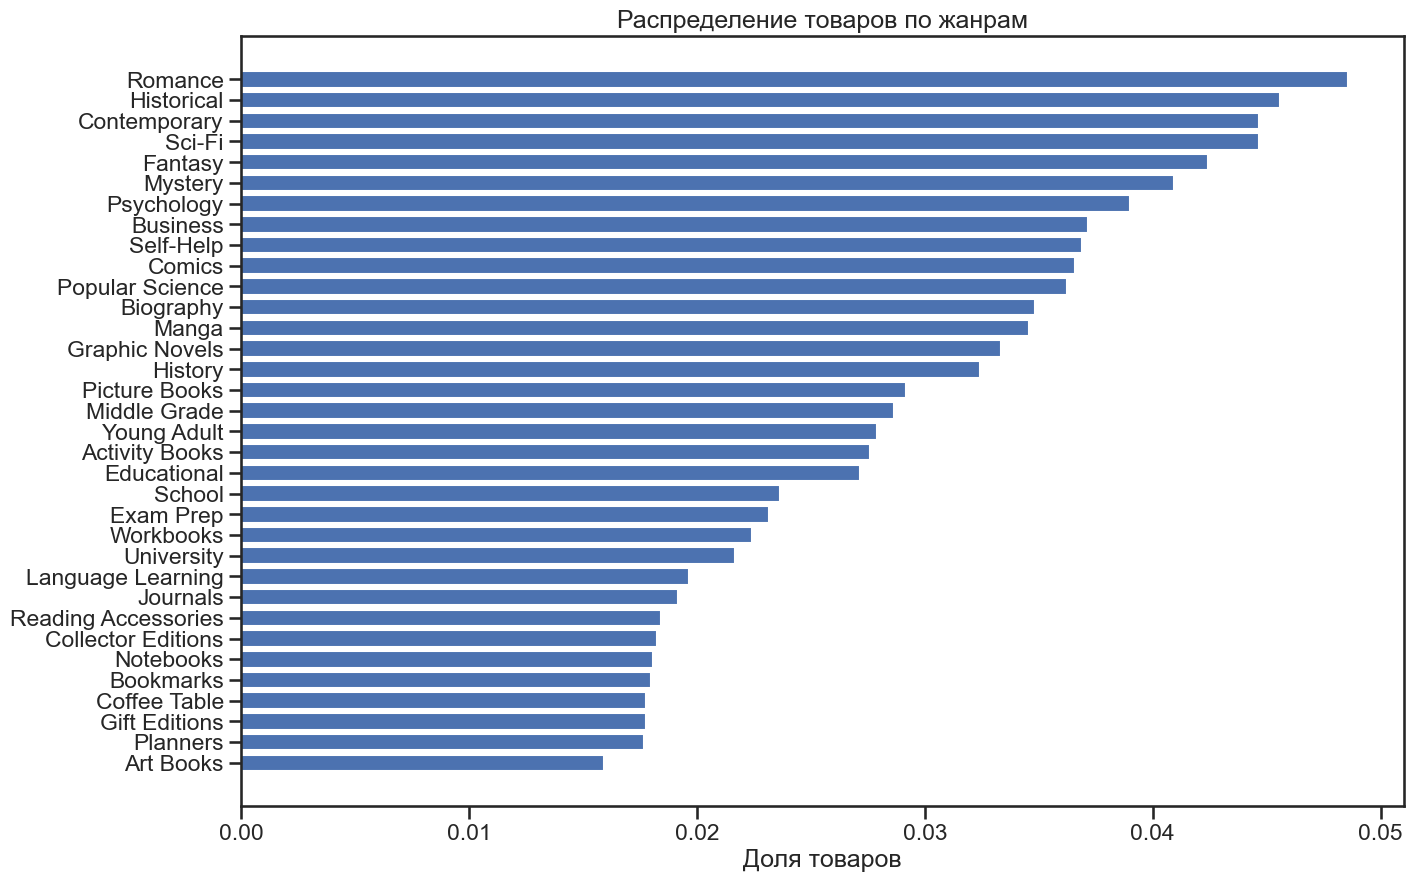

In [9]:
print(f"Всего поджанров: {df['subgenre'].nunique()}")
subgenre_table = (
    df_products['subgenre'].value_counts(normalize=True)
    .sort_values(ascending=False)
    .rename('share')
    .reset_index()
    .rename(columns={'index': 'subgenre'})
)

plt.figure(figsize=(15, 10))
plt.barh(subgenre_table['subgenre'][::-1], subgenre_table['share'][::-1])
plt.xlabel('Доля товаров')
plt.title('Распределение товаров по жанрам')
plt.show()

### ABC

In [10]:
def abc_analysis_by_group(
    df: pd.DataFrame,
    group_by: str,
    columns: list[str],
    thresholds: tuple[float, float] = (0.8, 0.95)) -> pd.DataFrame:    
    """
    Выполняет ABC-анализ по нескольким числовым колонкам
    с предварительной группировкой по одной колонке.
    """
    if group_by not in df.columns:
        raise KeyError(f"Колонка группировки '{group_by}' не найдена в DataFrame.")

    if not columns:
        raise ValueError("Список columns пуст.")

    missing_cols = [col for col in columns if col not in df.columns]
    if missing_cols:
        raise KeyError(f"Не найдены колонки: {missing_cols}")

    non_numeric_cols = [col for col in columns if not pd.api.types.is_numeric_dtype(df[col])]
    if non_numeric_cols:
        raise TypeError(
            f"Для ABC-анализа нужны числовые колонки. Нечисловые: {non_numeric_cols}"
        )

    first_threshold, second_threshold = thresholds
    if not (0 < first_threshold < second_threshold < 1):
        raise ValueError(
            "thresholds должны удовлетворять условию: 0 < first_threshold < second_threshold < 1"
        )
    
    df_metrics = (df.groupby(group_by, as_index=False)
                    .agg({col: 'sum' for col in columns}))
    
    for column in columns:
        abc_column = f"abc_by_{column}" 
        share_column = f"{column}_share"
        cum_share_column = f"{column}_cum_share"        
        total = df_metrics[column].sum()
        
        df_metrics[share_column] = df_metrics[column] / total
        df_metrics = df_metrics.sort_values(by=share_column, ascending=False)
        df_metrics[cum_share_column] = df_metrics[share_column].cumsum()
        
        df_metrics[abc_column] = pd.cut(
                df_metrics[cum_share_column],
                bins=[-float("inf"), first_threshold, second_threshold, float("inf")],
                labels=["A", "B", "C"],
                ordered=True,
            ).astype(str)
                
    return df_metrics

In [11]:
# Исключаем возвраты
df_abc = abc_analysis_by_group(df[df["item_status"] == 'completed'],
                               "subgenre",
                               ["net_revenue_item", "quantity_fulfilled"])

In [12]:
def color_abc(val):
    colors = {
        'A': 'background-color: #d9f2d9; color: #1f5e1f; font-weight: 600;',
        'B': 'background-color: #fff4cc; color: #7a5a00; font-weight: 600;',
        'C': 'background-color: #f8d7da; color: #842029; font-weight: 600;'
    }
    return colors.get(val, '')

cols = [
    'subgenre',
    'net_revenue_item',
    'net_revenue_item_share',
    'abc_by_net_revenue_item',
    'quantity_fulfilled',
    'quantity_fulfilled_share',
    'abc_by_quantity_fulfilled',    
]

(df_abc
    .sort_values(by=["net_revenue_item", "quantity_fulfilled"], ascending=False)[cols]
    .style
    .format({
        'net_revenue_item': '{:,.0f}',
        'net_revenue_item_share': '{:.2%}',
        'quantity_fulfilled': '{:,.0f}',
        'quantity_fulfilled_share': '{:.2%}',
    })
    .map(color_abc, subset=['abc_by_net_revenue_item', 'abc_by_quantity_fulfilled'])
    .hide(axis='index')
)

subgenre,net_revenue_item,net_revenue_item_share,abc_by_net_revenue_item,quantity_fulfilled,quantity_fulfilled_share,abc_by_quantity_fulfilled
School,"138,915,023",6.20%,A,"113,316",4.86%,A
Gift Editions,"104,826,320",4.68%,A,"37,992",1.63%,C
Coffee Table,"103,499,873",4.62%,A,"44,025",1.89%,B
Activity Books,"93,041,876",4.16%,A,"91,026",3.90%,A
Reading Accessories,"91,380,068",4.08%,A,"105,838",4.54%,A
Collector Editions,"82,084,011",3.67%,A,"33,371",1.43%,C
Business,"79,464,881",3.55%,A,"80,028",3.43%,A
Art Books,"77,920,944",3.48%,A,"33,447",1.43%,C
Self-Help,"77,800,390",3.47%,A,"80,384",3.45%,A
Middle Grade,"73,118,451",3.27%,A,"79,445",3.41%,A


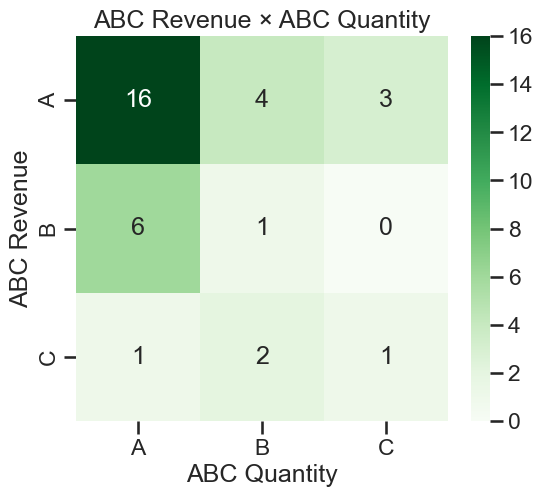

In [33]:
pivot = pd.crosstab(df_abc["abc_by_net_revenue_item"],
            df_abc["abc_by_quantity_fulfilled"])


plt.figure(figsize=(6, 5))
plt.barh(subgenre_table['subgenre'][::-1], subgenre_table['share'][::-1])
sns.heatmap(pivot, annot=True, fmt="d", cmap="Greens")
plt.xlabel('ABC Quantity')
plt.ylabel('ABC Revenue')
plt.title('ABC Revenue × ABC Quantity')
plt.show()

In [14]:
df_melt = df_abc.melt(
    id_vars='subgenre',
    value_vars=["abc_by_net_revenue_item", "abc_by_quantity_fulfilled"],
    var_name='metric',
    value_name='category'
)
df_melt = df_melt.groupby(["metric", "category"]).agg(count=("subgenre", "count")).reset_index()
df_melt

,metric,category,count
0,abc_by_net_revenue_item,A,23
1,abc_by_net_revenue_item,B,7
2,abc_by_net_revenue_item,C,4
3,abc_by_quantity_fulfilled,A,23
4,abc_by_quantity_fulfilled,B,7
5,abc_by_quantity_fulfilled,C,4


### XYZ

In [15]:
def xyz_analysis_by_group(
    df: pd.DataFrame,
    group_by:  str | list[str],
    period_col: str,
    columns: list[str],
    thresholds: tuple[float, float] = (0.15, 0.25)) -> pd.DataFrame:    
    """
    Выполняет XYZ-анализ по нескольким числовым колонкам
    с предварительной группировкой по одной и более колонке.   
    """
    first_threshold, second_threshold = thresholds
    
    if isinstance(group_by, str):
        group_by = [group_by]
        

    # 1. Агрегация внутри периода
    grouped = (
        df.groupby(group_by + [period_col], as_index=False)[columns]
          .sum()
    )
    

    # 2. Создать полный индекс всех сочетаний категорий и периодов, чтобы не оказалось пропусков,
    #  т.к. иначе периоды без продаж потеряются и вариативность исказится.
    unique_groups = [
        df[col].drop_duplicates().sort_values().tolist()
        for col in group_by
    ]
    unique_periods = df[period_col].drop_duplicates().sort_values().tolist()

    full_index = pd.MultiIndex.from_product(
        unique_groups + [unique_periods],
        names=group_by + [period_col]
    )
    
    # 3. Восстанавить пропущенные периоды и заполнить их нулями
    grouped_full = (
        grouped.set_index(group_by + [period_col])
               .reindex(full_index, fill_value=0)
               .reset_index()
    )
    
    # 4. Вычислить mean/std по каждой метрике
    result = (
        grouped_full.groupby(group_by, as_index=False)
        .agg(**{
            **{f"{col}_mean": (col, "mean") for col in columns},
            **{f"{col}_std": (col, "std") for col in columns},
        })
    )

    # 5. Вычислить CV (коэффициент вариации) и категорию XYZ
    columns_to_sort = []
    columns_to_drop = []
    for col in columns:
        mean_col = f"{col}_mean"
        std_col = f"{col}_std"
        cv_col = f"{col}_cv"
        xyz_col = f"{col}_xyz"
        columns_to_sort.append(cv_col)
        columns_to_drop.append(mean_col)
        columns_to_drop.append(std_col)

        result[cv_col] = np.where(
            result[mean_col] == 0,
            np.nan,
            result[std_col] / result[mean_col],
        )

        result[xyz_col] = pd.cut(
            result[cv_col],
            bins=[-float("inf"), first_threshold, second_threshold, float("inf")],
                labels=["X", "Y", "Z"],
            ordered=True,
            include_lowest=True,
        )
    
    result = result.drop(columns=columns_to_drop)
    result = result.sort_values(by=columns_to_sort)    
    return result

In [16]:
# Исключаем возвраты
df_xyz = xyz_analysis_by_group(df[df["item_status"] == 'completed'], "subgenre", "month", ["quantity_fulfilled"])
# Переиеменуем столбец, т.к. анализ проводился только по количеству.
df_xyz.rename(columns={"quantity_fulfilled_xyz": "xyz",}, inplace=True)

df_xyz["xyz"].value_counts()

xyz
Y    24
X     8
Z     2
Name: count, dtype: int64

In [18]:
def color_xyz(val):
    colors = {
        'X': 'background-color: #d9f2d9; color: #1f5e1f; font-weight: 600;',
        'Y': 'background-color: #fff4cc; color: #7a5a00; font-weight: 600;',
        'Z': 'background-color: #f8d7da; color: #842029; font-weight: 600;'
    }
    return colors.get(val, '')


(df_xyz   
    .style
    .format({        
        'quantity_fulfilled_cv': '{:.2%}'        
    })
    .map(
        lambda v: 'background-color: #f8d7da; color: #842029;' if v > 0.25 else '',
        subset=['quantity_fulfilled_cv']
    )
    .map(color_xyz, subset=['xyz'])
    .hide(axis='index')
)

subgenre,quantity_fulfilled_cv,xyz
Activity Books,13.15%,X
Middle Grade,13.28%,X
Self-Help,13.33%,X
Comics,13.33%,X
Biography,13.60%,X
Business,13.88%,X
Graphic Novels,14.11%,X
Psychology,14.88%,X
Sci-Fi,15.11%,Y
Young Adult,15.32%,Y


### ABC+ XYZ

In [19]:
df_abc_xyz = (df_abc.merge(df_xyz, on="subgenre"))
df_abc_xyz["abc"] = (df_abc_xyz["abc_by_net_revenue_item"].astype(str) +
                     df_abc_xyz["abc_by_quantity_fulfilled"].astype(str))
df_abc_xyz["abc_xyz"] = (df_abc_xyz["abc"].astype(str) +
                         df_abc_xyz["xyz"].astype(str))

df_abc_xyz.head()

,subgenre,net_revenue_item,quantity_fulfilled,net_revenue_item_share,net_revenue_item_cum_share,abc_by_net_revenue_item,quantity_fulfilled_share,quantity_fulfilled_cum_share,abc_by_quantity_fulfilled,quantity_fulfilled_cv,xyz,abc,abc_xyz
0,School,138915023.35,113316,0.06,0.06,A,0.05,0.05,A,0.20,Y,AA,AAY
1,Reading Accessories,91380068.04,105838,0.04,0.24,A,0.05,0.09,A,0.16,Y,AA,AAY
2,Mystery,71232760.65,97439,0.03,0.44,A,0.04,0.14,A,0.19,Y,AA,AAY
3,Romance,65373920.37,97094,0.03,0.57,A,0.04,0.18,A,0.17,Y,AA,AAY
4,Sci-Fi,70234842.58,95832,0.03,0.47,A,0.04,0.22,A,0.15,Y,AA,AAY


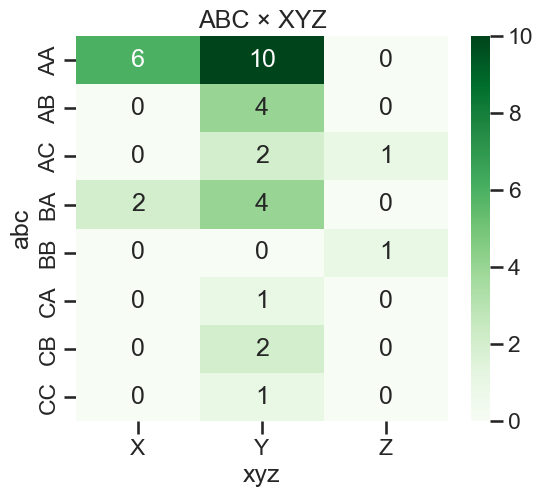

In [35]:
pivot = pd.crosstab(df_abc_xyz['abc'], df_abc_xyz['xyz'])


plt.figure(figsize=(6, 5))
plt.barh(subgenre_table['subgenre'][::-1], subgenre_table['share'][::-1])
sns.heatmap(pivot, annot=True, fmt="d", cmap="Greens")
plt.title('ABC × XYZ')
plt.show()

In [38]:
cols = [
    'subgenre',
    'net_revenue_item',
    'net_revenue_item_share',   
    'quantity_fulfilled',
    'quantity_fulfilled_share',    
    'quantity_fulfilled_cv',
    'abc_xyz',    
]
df_abc_xyz.sort_values(by=['abc_xyz', "net_revenue_item", "quantity_fulfilled"],
    ascending=[True, False, False]) \
  [cols] \
  .style \
  .background_gradient(subset=['net_revenue_item'], cmap='Greens') \
  .background_gradient(subset=['quantity_fulfilled'], cmap='Blues') \
  .background_gradient(subset=['quantity_fulfilled_cv'], cmap='Reds')

,subgenre,net_revenue_item,net_revenue_item_share,quantity_fulfilled,quantity_fulfilled_share,quantity_fulfilled_cv,abc_xyz
6,Activity Books,93041875.980000,0.041550,91026,0.039037,0.131509,AAX
9,Business,79464880.900000,0.035487,80028,0.034320,0.138770,AAX
8,Self-Help,77800389.530000,0.034744,80384,0.034473,0.133306,AAX
10,Middle Grade,73118451.430000,0.032653,79445,0.034070,0.132773,AAX
13,Graphic Novels,70207002.580000,0.031353,76853,0.032959,0.141062,AAX
18,Psychology,61967838.320000,0.027673,63305,0.027149,0.148825,AAX
0,School,138915023.350000,0.062036,113316,0.048596,0.201569,AAY
1,Reading Accessories,91380068.040000,0.040808,105838,0.045389,0.160666,AAY
2,Mystery,71232760.650000,0.031811,97439,0.041787,0.193945,AAY
4,Sci-Fi,70234842.580000,0.031365,95832,0.041098,0.151095,AAY


In [21]:
def print_categories_summary(df, category):
    summary = (df.groupby(category, as_index=False, observed=False)
                    .agg(
                        subgenres=('subgenre', 'count'),                        
                        revenue_share=('net_revenue_item_share', 'sum'),
                        qty_share=('quantity_fulfilled_share', 'sum')
                    )
                    .sort_values(category)
                    .rename(columns={category: "category"})                    
              )
    
    total = summary['subgenres'].sum()
    summary['subgenre_share'] = summary['subgenres'] / total

    
    for row in summary.itertuples(index=False):        
        print(
            f"- {row.category}: {row.subgenres} поджанров ({row.subgenre_share:.2%}), "
            f"доля в выручке — {row.revenue_share:.2%}, "
            f"доля в количестве продаж — {row.qty_share:.2%}."
        )
    

print("Структура ABC сегментации:")
print_categories_summary(df_abc_xyz, "abc")

print("\nСтруктура XYZ сегментации:")
print_categories_summary(df_abc_xyz, "xyz")

print("\nСтруктура ABC-XYZ сегментации:")
print_categories_summary(df_abc_xyz, "abc_xyz")

Структура ABC сегментации:
- AA: 16 поджанров (47.06%), доля в выручке — 53.16%, доля в количестве продаж — 58.35%.
- AB: 4 поджанров (11.76%), доля в выручке — 12.79%, доля в количестве продаж — 8.79%.
- AC: 3 поджанров (8.82%), доля в выручке — 11.83%, доля в количестве продаж — 4.49%.
- BA: 6 поджанров (17.65%), доля в выручке — 14.07%, доля в количестве продаж — 17.89%.
- BB: 1 поджанров (2.94%), доля в выручке — 2.42%, доля в количестве продаж — 1.83%.
- CA: 1 поджанров (2.94%), доля в выручке — 1.42%, доля в количестве продаж — 2.59%.
- CB: 2 поджанров (5.88%), доля в выручке — 3.16%, доля в количестве продаж — 4.33%.
- CC: 1 поджанров (2.94%), доля в выручке — 1.15%, доля в количестве продаж — 1.72%.

Структура XYZ сегментации:
- X: 8 поджанров (23.53%), доля в выручке — 25.02%, доля в количестве продаж — 25.73%.
- Y: 24 поджанров (70.59%), доля в выручке — 67.88%, доля в количестве продаж — 70.80%.
- Z: 2 поджанров (5.88%), доля в выручке — 7.11%, доля в количестве продаж — 3.4

In [23]:
def print_top_subgenres(df, metric, top_n=5):    
    top_df = df.nlargest(top_n, metric, keep='all')

    metric_name = {
        'net_revenue_item': 'выручке',
        'quantity_fulfilled': 'количеству продаж'
    }.get(metric, metric)

    print(f"Топ-{top_n} по {metric_name}:")
    for i, row in enumerate(top_df.itertuples(index=False), 1):
        print(
            f"{i}. {row.subgenre} ({row.abc_xyz}) — "
            f"{format_compact_decimal(row.quantity_fulfilled, locale='en_US')} продаж, "
            f"{format_compact_currency(row.net_revenue_item, 'RUB', locale='ru_RU')} выручки"
        )
        
print_top_subgenres(df_abc_xyz, 'net_revenue_item', top_n=5)
print()
print_top_subgenres(df_abc_xyz, 'quantity_fulfilled', top_n=5)

top_abc_xyz = df_abc_xyz.sort_values(
    by=['abc_xyz', "net_revenue_item", "quantity_fulfilled"],
    ascending=[True, False, False]).head(10)

print('')
print("Топ-10 по продажам, выручке и стабильности:")
for i, row in enumerate(top_abc_xyz.itertuples(), 1):
    print(
        f"{i}. {row.subgenre} ({row.abc_xyz}) — {format_compact_decimal(row.quantity_fulfilled, locale='en_US')} продаж, " +
        f"{format_compact_currency(row.net_revenue_item, 'RUB', locale='ru_RU')} выручки"
    )

Топ-5 по выручке:
1. School (AAY) — 113K продаж, 139 млн ₽ выручки
2. Gift Editions (ACZ) — 38K продаж, 105 млн ₽ выручки
3. Coffee Table (ABY) — 44K продаж, 103 млн ₽ выручки
4. Activity Books (AAX) — 91K продаж, 93 млн ₽ выручки
5. Reading Accessories (AAY) — 106K продаж, 91 млн ₽ выручки

Топ-5 по количеству продаж:
1. School (AAY) — 113K продаж, 139 млн ₽ выручки
2. Reading Accessories (AAY) — 106K продаж, 91 млн ₽ выручки
3. Mystery (AAY) — 97K продаж, 71 млн ₽ выручки
4. Romance (AAY) — 97K продаж, 65 млн ₽ выручки
5. Sci-Fi (AAY) — 96K продаж, 70 млн ₽ выручки

Топ-10 по продажам, выручке и стабильности:
1. Activity Books (AAX) — 91K продаж, 93 млн ₽ выручки
2. Business (AAX) — 80K продаж, 79 млн ₽ выручки
3. Self-Help (AAX) — 80K продаж, 78 млн ₽ выручки
4. Middle Grade (AAX) — 79K продаж, 73 млн ₽ выручки
5. Graphic Novels (AAX) — 77K продаж, 70 млн ₽ выручки
6. Psychology (AAX) — 63K продаж, 62 млн ₽ выручки
7. School (AAY) — 113K продаж, 139 млн ₽ выручки
8. Reading Accessor

In [42]:
def print_bottom_subgenres(df, metric, top_n=5):    
    top_df = df.nsmallest(top_n, metric, keep='all')

    metric_name = {
        'net_revenue_item': 'выручке',
        'quantity_fulfilled': 'количеству продаж'
    }.get(metric, metric)

    print(f"Антилидеры по {metric_name}:")
    for i, row in enumerate(top_df.itertuples(index=False), 1):
        print(
            f"{i}. {row.subgenre} ({row.abc_xyz}) — "
            f"{format_compact_decimal(row.quantity_fulfilled, locale='en_US')} продаж, "
            f"{format_compact_currency(row.net_revenue_item, 'RUB', locale='ru_RU')} выручки"
        )
        
print_bottom_subgenres(df_abc_xyz, 'net_revenue_item', top_n=5)
print()
print_bottom_subgenres(df_abc_xyz, 'quantity_fulfilled', top_n=5)

bottom_abc_xyz = df_abc_xyz.sort_values(
    by=['abc_xyz', "net_revenue_item", "quantity_fulfilled"],
    ascending=[False, True, True]).head(10)

print('')
print("Антилидеры по продажам, выручке и стабильности:")
for i, row in enumerate(bottom_abc_xyz.itertuples(), 1):
    print(
        f"{i}. {row.subgenre} ({row.abc_xyz}) — {format_compact_decimal(row.quantity_fulfilled, locale='en_US')} продаж, " +
        f"{format_compact_currency(row.net_revenue_item, 'RUB', locale='ru_RU')} выручки"
    )

Антилидеры по выручке:
1. Planners (CCY) — 40K продаж, 26 млн ₽ выручки
2. Bookmarks (CBY) — 47K продаж, 31 млн ₽ выручки
3. Notebooks (CAY) — 61K продаж, 32 млн ₽ выручки
4. Journals (CBY) — 54K продаж, 40 млн ₽ выручки
5. Educational (BAY) — 64K продаж, 50 млн ₽ выручки

Антилидеры по количеству продаж:
1. Collector Editions (ACY) — 33K продаж, 82 млн ₽ выручки
2. Art Books (ACY) — 33K продаж, 78 млн ₽ выручки
3. Gift Editions (ACZ) — 38K продаж, 105 млн ₽ выручки
4. Planners (CCY) — 40K продаж, 26 млн ₽ выручки
5. Language Learning (BBZ) — 43K продаж, 54 млн ₽ выручки

Антилидеры по продажам, выручке и стабильности:
1. Planners (CCY) — 40K продаж, 26 млн ₽ выручки
2. Bookmarks (CBY) — 47K продаж, 31 млн ₽ выручки
3. Journals (CBY) — 54K продаж, 40 млн ₽ выручки
4. Notebooks (CAY) — 61K продаж, 32 млн ₽ выручки
5. Language Learning (BBZ) — 43K продаж, 54 млн ₽ выручки
6. Educational (BAY) — 64K продаж, 50 млн ₽ выручки
7. Young Adult (BAY) — 66K продаж, 52 млн ₽ выручки
8. Historical

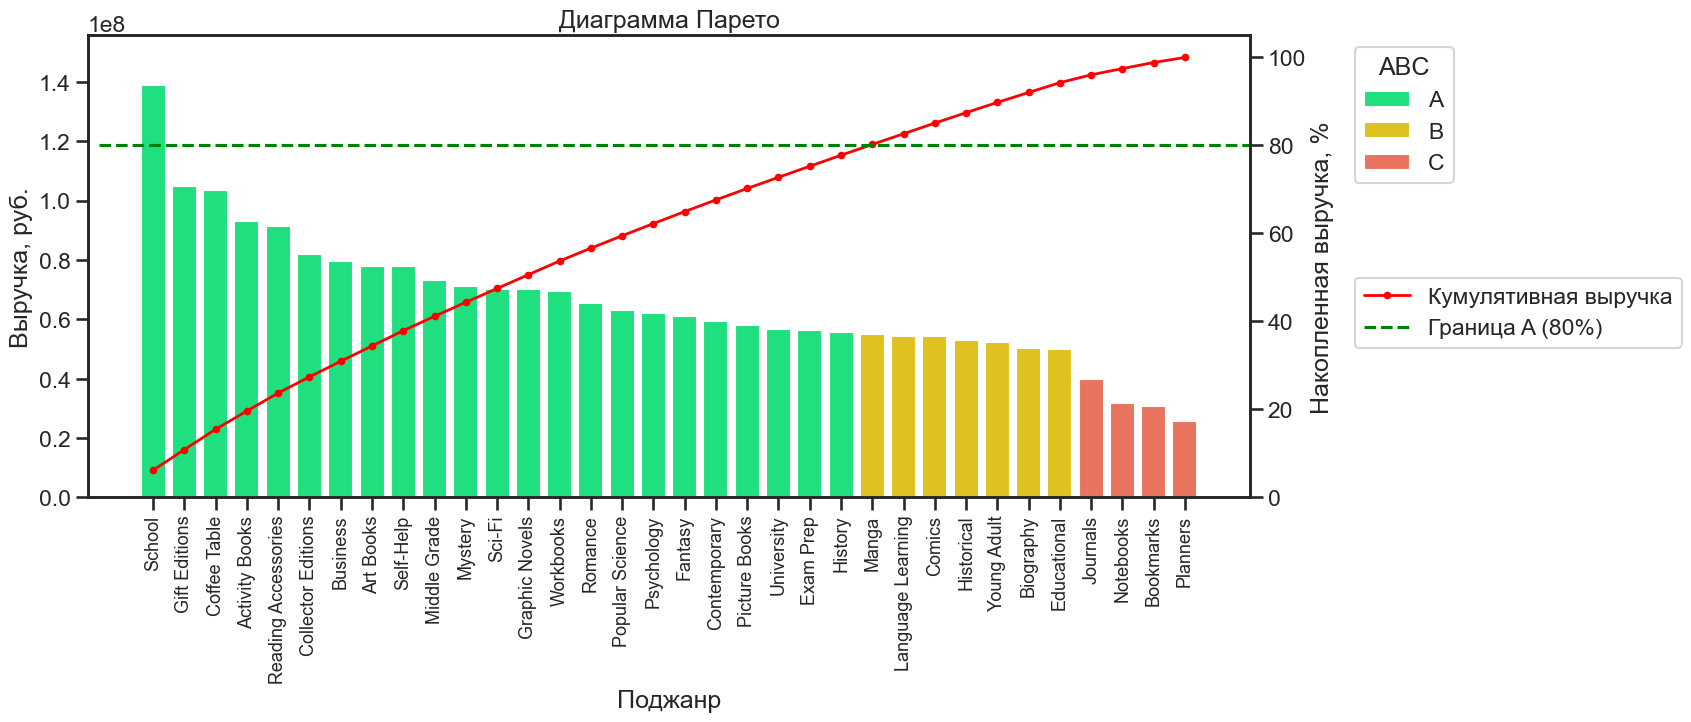

In [24]:
df_pareto = df_abc_xyz.sort_values('net_revenue_item_cum_share',
                                   ascending=True).reset_index()
palette = {
    'A': '#00FF7F',  # зелёный
    'B': '#FFD700',  # жёлтый
    'C': '#FF6347'  # красный
}

fig, ax1 = plt.subplots(figsize=(15, 6))

# бары — выручка
sns.barplot(x='subgenre',
            y='net_revenue_item',
            data=df_pareto,
            ax=ax1,
            dodge=False,
            hue='abc_by_net_revenue_item',
            palette=palette)

ax1.set_ylabel('Выручка, руб.')
ax1.set_xlabel('Поджанр')
ax1.set_ylim(0, df_pareto['net_revenue_item'].max() * 1.12)
ax1.tick_params(axis='x', labelrotation=90, labelsize=13)
ax1.legend(title='ABC', bbox_to_anchor=(1.08, 1), loc='upper left')


# Вторая ось для накопленного процента
ax2 = ax1.twinx()
ax2.plot(df_pareto['net_revenue_item_cum_share'].values * 100,
         color='red',
         marker='.',
         linewidth=2,
        label="Кумулятивная выручка")
ax2.set_ylabel('Накопленная выручка, %')
ax2.set_ylim(0, 105)

# Линия 80% (опционально)
ax2.axhline(80, xmin=0.01, color="green", linestyle="--", label="Граница A (80%)")
ax2.legend(bbox_to_anchor=(1.08, 0.5), loc='upper left')

plt.title('Диаграмма Парето')
plt.show()

### Выводы

#### Общая картина распределения ассортимента:

* **Всего проанализировано:** 34 поджанра (подкатегории) книжной продукции, проданной за 2025 года

* **Ядро ассортимента (AA категории):** 16 поджанров (47%) дают основную часть продаж и выручки

* **Стабильность спроса:** 
    - 8 поджанров (23.53%) имеют стабильный спрос (X)
    - 24 (70.59%) - переменный (Y)
    - 2 (5.88%) - нестабильный (Z)

📌 **Вывод:** Бизнес опирается на широкий ассортимент, но значительная часть ассортимента имеет колеблющийся спрос.

#### Стабильные лидеры (AAX - много продаж, много выручки, стабильный спрос)

Небольшое количество категорий (6 поджанров, 17.65 %) формирует 20% выручки при низкой вариативности спроса (CV ~0.13–0.15). Это предсказуемый и устойчивый источник дохода.

**Топ-5 наиболее ценных поджанра (AAX):**
1. Activity Books — 91K продаж, 93 млн ₽ выручки
2. Business — 80K продаж, 79 млн ₽ выручки
3. Self-Help — 80K продаж, 78 млн ₽ выручки
4. Middle Grade — 79K продаж, 73 млн ₽ выручки
5. Graphic Novels — 77K продаж, 70 млн ₽ выручки

#### Ключевые сегменты с риском (AAY)
Несмотря на наличие стабильного ядра (AAX), значительная часть (33%) выручки зависит от категорий с вариативным спросом (AAY).

**Топ-5 по количеству продаж:**
1. School (AAY) — 113K продаж, 139 млн ₽ выручки (лидер и по выручке и по продажам)
2. Reading Accessories (AAY) — 106K продаж, 91 млн ₽ выручки
3. Mystery (AAY) — 97K продаж, 71 млн ₽ выручки
4. Romance (AAY) — 97K продаж, 65 млн ₽ выручки
5. Sci-Fi (AAY) — 96K продаж, 70 млн ₽ выручки

📌**Вывод:** основной объём бизнеса зависит от категорий с нестабильным спросом

📌**Действие**: проанализировать сезонность, внедрить более точное прогнозирование и буфферные запасы.

#### Позиции, требующие внимания:
* **Gift Editions (ACZ) - премиум сегмент (высокая выручка при небольших продажах), нестабильный спрос**    
    - 38K продаж, 105 млн ₽ выручки
    - ABC: A по выручке (высокая доходность), но С по количеству (низкие продажи)
    - XYZ: Z - один из самых высоких коэффициентов вариации (0.27)
    - Действие: проанализировать сезонность, закупки под сезоны

* **Language Learning (BBZ) — нестабильный спрос** 
    - 43K продаж, 54 млн ₽ выручки
    - Один из самых высоких коэффициентов вариации - 0.27
    - Действие: ограничение складских запасов, анализ драйверов спроса

* **Notebooks(CAY), Bookmarks(CBY), Planners(CCY) — низкая выручка, нестабильный спрос**
    - Notebooks (CAY) - продажи высокие, но выручка низкая
    - Bookmarks(CBY) - продажи средние, но выручка низкая
    - Planners(CCY) - продадажи низкие, выручка низкая
    - Нестабильный спрос  
    - Действие: оптимизация или сокращение ассортимента
* **Comics, Biography (BAX) — стабильный средний сегмент**
    - стабильный спрос, высокие продажи и средняя выручка
    - Действие: перевод в A-категорию через маркетинг и расширение ассортимента
* **Coffee Table / Art / Collector Editions (AB / AC) - высокая выручка, низкий объем**
    - Потенциально премиум-сегмент с высокой выручкой

#### Рекомендации:
- Для категории AAX: обеспечить постоянную доступность, минимизировать out-of-stock, автоматизировать закупки
- Для категории AAY: внедрить прогнозирование спроса, увеличить запасы
- Для категорий Z: проанализироват сезонность, закупки под сезоны
- Для категорий С (по выручке): допольнительный анализ ассортимента, сокращение нерентабельных позиций
- Для категорий B (по выручке): развитие сегмента через ассортимент, доступность и маркетинг

**Проведённый анализ показывает, что бизнес имеет сильное и стабильное ядро (AAX),  однако значительная часть выручки формируется за счёт категорий с переменным спросом (AAY), что увеличивает операционные и финансовые риски. 
Ключевая задача бизнеса заключается не в расширении ассортимента, а в управлении стабильностью спроса и оптимизации текущей товарной матрицы.**